In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Advertising.csv', index_col = 0)
df.head()

,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


In [3]:
X = df.drop('Sales', axis = 1)
X.head()

,TV,Radio,Newspaper
1,230.1,37.8,69.2
2,44.5,39.3,45.1
3,17.2,45.9,69.3
4,151.5,41.3,58.5
5,180.8,10.8,58.4


In [4]:
y = df['Sales']

## Polynomial regression

In [5]:
from sklearn.preprocessing import PolynomialFeatures

In [6]:
polynomial_converter = PolynomialFeatures(degree = 2, include_bias=False)

In [7]:
polynomial_converter

PolynomialFeatures(include_bias=False)

In [8]:
polynomial_converter.fit(X) # fit(X) basically tells here is the data we want you to convert. Model has not yet been created

PolynomialFeatures(include_bias=False)

In [9]:
poly_feature = polynomial_converter.transform(X) # or we can just do polynomial_converted.fit_transform(x)

In [10]:
X.iloc[0]

TV           230.1
Radio         37.8
Newspaper     69.2
Name: 1, dtype: float64

In [11]:
poly_feature[0]
# the first three values are the same, then interactions terms, then squared termsb

array([2.301000e+02, 3.780000e+01, 6.920000e+01, 5.294601e+04,
       8.697780e+03, 1.592292e+04, 1.428840e+03, 2.615760e+03,
       4.788640e+03])

### Train test split

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(poly_feature, y, test_size=0.3, random_state=101)

### creating the model

In [14]:
from sklearn.linear_model import LinearRegression

In [15]:
model = LinearRegression()

In [16]:
model.fit(X_train, y_train)

LinearRegression()

In [17]:
test_predictions = model.predict(X_test)

### checking accuracy

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [19]:
MAE = mean_absolute_error(y_test, test_predictions)
MSE = mean_squared_error(y_test, test_predictions)

In [20]:
RMSE = np.sqrt(MSE)

In [21]:
MAE

0.4896798044803556

In [22]:
RMSE

np.float64(0.6646431757269032)

## Choosing the degree of polynomial

In [38]:
# Ceate different order polynomial
# split into train/ test
# store/save the rmse for both the train and test
# plot the error vs poly degree

In [23]:
train_rmse_error = []
test_rmse_error = []

for d in range(1, 10):
    poly_converted = PolynomialFeatures(degree = d, include_bias = False)

    poly_features = poly_converted.fit_transform(X)
    
    X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.33, random_state=42)
    
    model = LinearRegression()
    model.fit(X_train, y_train)

    train_predictions = model.predict(X_train)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))

    test_predictions = model.predict(X_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))

    train_rmse_error.append(train_rmse)
    test_rmse_error.append(test_rmse)

In [24]:
train_rmse_error

[np.float64(1.5526939990087725),
 np.float64(0.6057702019226606),
 np.float64(0.47568472931843425),
 np.float64(0.3742987908933814),
 np.float64(0.2410875850809417),
 np.float64(0.22044269288522272),
 np.float64(0.21968513371315163),
 np.float64(0.28088750099818427),
 np.float64(0.5635860390426607)]

In [25]:
test_rmse_error

[np.float64(1.9307843822347202),
 np.float64(0.6784587307926792),
 np.float64(0.5148267621898044),
 np.float64(1.2750589603908589),
 np.float64(6.410848666271319),
 np.float64(20.2221596596857),
 np.float64(104.66449460252348),
 np.float64(4697.538099895839),
 np.float64(6350.0383986866955)]

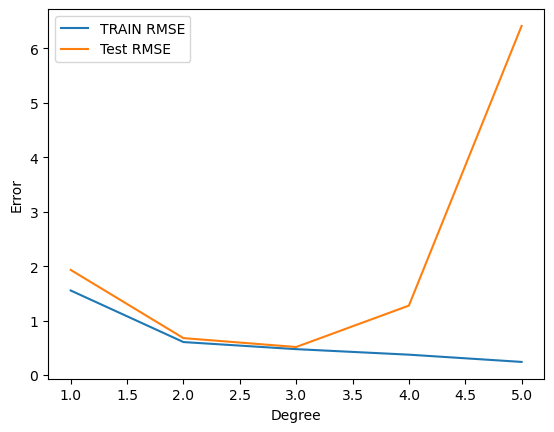

In [29]:
plt.plot(range(1, 6), train_rmse_error[:5], label = "TRAIN RMSE")
plt.plot(range(1, 6), test_rmse_error[:5], label = "Test RMSE")
plt.xlabel("Degree")
plt.ylabel("Error")
plt.legend()

### Model deployment

In [30]:
final_poly_converter = PolynomialFeatures(degree = 3, include_bias = False)

In [31]:
final_model = LinearRegression()

In [33]:
full_converted_x = final_poly_converter.fit_transform(X)
final_model.fit(full_converted_x, y)

LinearRegression()

In [34]:
from joblib import dump, load

In [35]:
dump(final_model, 'final_poly_model.joblib')

['final_poly_model.joblib']

In [36]:
dump(final_poly_converter, 'final_converted.joblib')

['final_converted.joblib']